In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#### Loading The Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Sumit\OneDrive\Desktop\LUCY\Dataset\Lucy_english_dataset.csv")

In [3]:
selected_emotions = ["happiness", "sadness", "anger","surprise","love"]
df = df[df["emotion"].isin(selected_emotions)]

In [4]:
emotion_map = {
    "happiness": "happy",
    "sadness": "sad",
    "anger": "angry",
    "surprise":"surprise",
    "love":"love"
}

df["emotion"] = df["emotion"].map(emotion_map)

In [5]:
df.head()

,text,emotion
1,i feel surprised by the result,surprise
3,i suddenly found myself standing before this w...,surprise
5,"I, for one, am thrilled that Christ works outs...",happy
8,i have personally experienced this gut wrenchi...,sad
10,Branson was nonplussed by Elliott 's refusal ;...,surprise


### EDA

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 49999 entries, 1 to 106354
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     49999 non-null  str  
 1   emotion  49999 non-null  str  
dtypes: str(2)
memory usage: 1.1 MB


In [7]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [8]:
df.shape

(49999, 2)

In [9]:
df.describe()

,text,emotion
count,49999,49999
unique,42421,5
top,"RT, follow and WIN one of the 5 special collec...",surprise
freq,23,10000


In [10]:
df.duplicated().sum()

np.int64(7562)

In [11]:
df.duplicated(subset=["text"]).sum()

np.int64(7578)

In [12]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()

text
Why not ?                                                                                                       2
BTW I STILL can't believe how Awesome the NEWJABBAKIDZ performance was...U in the masks..I screamed at my pc    2
FREE UNLIMITED RINGTONES!!! - - USA ONLY - Awesome 4 iphone                                                     2
Round and Round the Garden: The amazing thing is that he's still talking to me!                                 2
Will do                                                                                                         2
Name: emotion, dtype: int64

In [13]:
df['emotion'].value_counts()

emotion
surprise    10000
happy       10000
love        10000
angry       10000
sad          9999
Name: count, dtype: int64

### Removing Dublicates

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
valid_texts = df.groupby("text")["emotion"].nunique()
valid_texts = valid_texts[valid_texts == 1].index

df = df[df["text"].isin(valid_texts)]

In [17]:
df.shape

(42405, 2)

In [18]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()

text
! HE HAS A FAVOURITE! You're his favourite ;) OMGAAH. sorry for creepering? really lol    1
! RT : C'est confirmé! Nous aurons toute une activité pour la de ! Détails à venir!       1
! please follow so that we can keep our updates and stuff there use it to spread word     1
!! ... maybe they took one look at you and said &quot;That's our girl!&quot;              1
!!! Tell us your experience! I Loveeeee Youu!                                             1
Name: emotion, dtype: int64

In [19]:
df['emotion'].value_counts()

emotion
sad         9308
happy       9146
love        8579
surprise    7910
angry       7462
Name: count, dtype: int64

<Axes: xlabel='emotion', ylabel='count'>

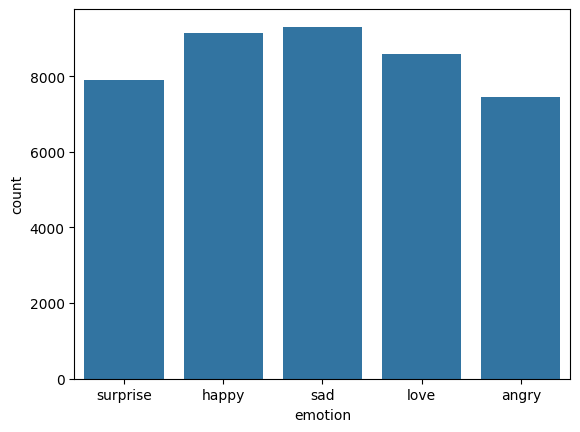

In [20]:
sns.countplot(x="emotion", data=df)

In [21]:
df["text_length"] = df["text"].apply(len)
df["text_length"].describe()

count    42405.000000
mean        99.151350
std         56.283912
min          4.000000
25%         57.000000
50%         90.000000
75%        127.000000
max        830.000000
Name: text_length, dtype: float64

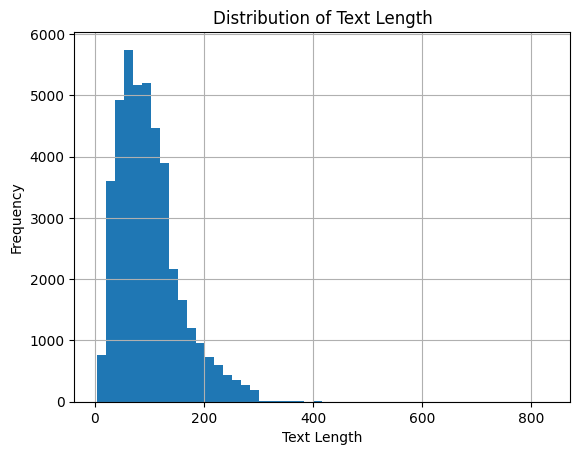

In [22]:
df["text_length"].hist(bins=50)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length")
plt.show()

#### Test Train Split 

In [23]:
X = df['text']
y = df['emotion']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)


### TF - IDF VECTORIZER

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    max_features=10000,
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### CHEKING FOR EMPTY VECTORIZER

In [30]:
(X_train_tfidf.sum(axis =1) ==0).sum()


np.int64(83)

In [31]:
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression()

### LOgistic Regression

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["saga"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}
Best Score: 0.7934500311105241


### Naive Bias 

In [ ]:
from sklearn.naive_bayes import MultinomialNB


param_grid_nb = {
    "alpha": [0.01, 0.1, 0.5, 1, 2]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_nb.fit(X_train_tfidf, y_train)

print("Best NB Params:", grid_nb.best_params_)
print("Best NB Score:", grid_nb.best_score_)

Best NB Params: {'alpha': 2}
Best NB Score: 0.7405966659598725


### SVM 

In [35]:
from sklearn.svm import LinearSVC

param_grid_svm = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["hinge", "squared_hinge"]
}

grid_svm = GridSearchCV(
    LinearSVC(max_iter=5000),
    param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_tfidf, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

Best SVM Params: {'C': 0.1, 'loss': 'squared_hinge'}
Best SVM Score: 0.7933615442638451


### Final Model Selection 

In [36]:
lg = LogisticRegression(
    max_iter=1000,
    C=1,
    solver='saga',
    random_state=42,
    penalty='l2',
    class_weight='balanced'
)


lg.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclas

In [37]:
y_predict = lg.predict(X_test_tfidf)

### Accuracy and Classifiacton Reprot

In [38]:
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

accuracy_score(y_test,y_predict)


0.7989623865110247

In [39]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

       angry       0.87      0.85      0.86      1492
       happy       0.80      0.76      0.78      1829
        love       0.92      0.92      0.92      1716
         sad       0.73      0.73      0.73      1862
    surprise       0.69      0.75      0.72      1582

    accuracy                           0.80      8481
   macro avg       0.80      0.80      0.80      8481
weighted avg       0.80      0.80      0.80      8481



In [40]:
lg.score(X_train_tfidf,y_train)


0.878021459733522

In [41]:
from sklearn.metrics import confusion_matrix

In [43]:
confusion_matrix(y_test,y_predict)

array([[1263,   30,   10,  117,   72],
       [  37, 1397,   42,  156,  197],
       [  13,   61, 1573,   35,   34],
       [  94,  128,   50, 1363,  227],
       [  39,  137,   32,  194, 1180]])

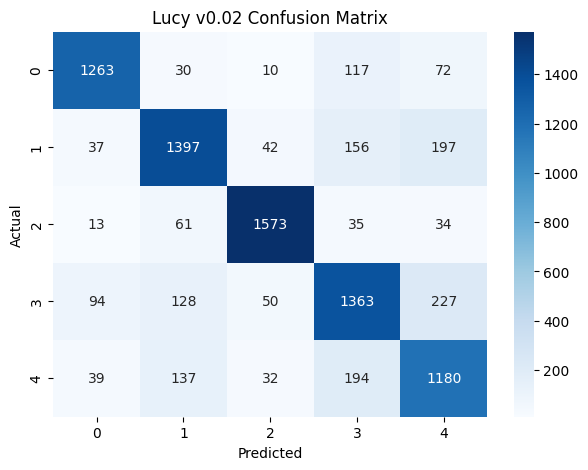

In [44]:


y_pred = lg.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Lucy v0.02 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()